# 03 — Variational Autoencoder (VAE) per Anomaly Detection: Emerging Jets

## Obiettivo

Costruire un **Variational Autoencoder (VAE)** per rilevare Emerging Jets come anomalie,
partendo dall'Autoencoder flat del notebook precedente e migliorandone la struttura interna.

L'idea di fondo rimane la stessa:

> *Addestriamo il modello **esclusivamente su jet QCD** (background ordinario).
> Un Emerging Jet — con le sue tracce displaced e la sua struttura anomala —
> verrà ricostruito **male**, e l'errore di ricostruzione diventa il nostro **anomaly score**.*

Quello che cambia è **come** il modello comprime l'informazione al suo interno.
Capire questa differenza è il cuore di questo notebook.

---

## Struttura del notebook

| Sezione | Contenuto |
|---|---|
| 1 | Setup — import e iperparametri |
| 2 | Caricamento dati (solo `aggregate`) |
| 3 | Dataset e DataLoader |
| 4 | Architettura del VAE |
| 5 | Loss function: ricostruzione + KL divergence |
| 6 | Training loop |
| 7 | Anomaly score |
| 8 | Valutazione — ROC, AUC, SIC |
| 9 | Tuning sistematico |

---

# Dal Flat Autoencoder al VAE — Cosa cambia e perché

## Cosa fa il tuo Flat Autoencoder (notebook 02)

Il modello del notebook precedente è un **Autoencoder MLP flat**.
"Flat" significa che l'input è un vettore da 43 numeri (la rappresentazione `aggregate`
che calcola media, massimo e deviazione standard delle 14 feature di traccia per ogni jet)
e ci si costruisce sopra un MLP classico.

L'architettura è:

```
x (43)  →  Encoder  →  z (32)  →  Decoder  →  x̂ (43)
```

Il punto chiave è che `z` è un **vettore deterministico**: dato lo stesso jet in input,
l'encoder produce sempre e solo lo stesso vettore `z`. Non c'è nessuna componente casuale.

Il modello si addestra minimizzando la sola **loss di ricostruzione**:

$$\mathcal{L}_{\text{AE}} = \frac{1}{D} \sum_{i=1}^{D}(x_i - \hat{x}_i)^2 = \text{MSE}(x, \hat{x})$$

Non esiste nessun vincolo su dove i punti `z` finiscono nello spazio latente.
La rete li posiziona dove vuole, purché minimizzi l'MSE.

---

## Lo spazio latente — il problema del Flat AE

Ogni jet, dopo essere passato attraverso l'encoder, diventa un punto in uno spazio matematico
a 32 dimensioni: lo **spazio latente**. Puoi immaginarlo come una mappa dove ogni jet
occupa una posizione — jet simili tra loro (stesso tipo di struttura QCD) dovrebbero finire
vicini, jet diversi (Emerging Jets) dovrebbero finire lontani.

Il problema del Flat AE è che **non c'è nessun vincolo su questa mappa**.
L'encoder impara a minimizzare l'MSE, e basta. Il risultato pratico è che lo
spazio latente può essere caotico:

- I punti possono essere ammassati in un angolo e sparsi in modo irregolare
- Possono esserci **grandi zone vuote** — regioni dello spazio che non corrispondono
  a nessun jet reale
- Punti vicini nello spazio latente non corrispondono necessariamente a jet fisicamente simili

Questo non è un grosso problema per la sola ricostruzione (l'AE funziona comunque),
ma rende lo spazio latente **geometricamente disorganizzato**.
Per l'anomaly detection questo conta: vorremmo che i jet QCD occupassero una regione
compatta e ben definita, e che gli EJ cadessero chiaramente fuori da quella regione.
Il Flat AE non garantisce questo.

Il VAE risolve esattamente questo problema.

---

## Come funziona il VAE — la differenza fondamentale

Nel VAE l'encoder **non produce un singolo vettore** `z`.
Produce invece i parametri di una **distribuzione gaussiana**:
un vettore di medie **μ** e un vettore di varianze **σ²**, entrambi di dimensione `latent_dim`.

```
x (43)  →  Encoder  →  μ (32)  e  log σ² (32)
                            ↓
                     z ~ N(μ, σ²)      ← z viene CAMPIONATO da questa gaussiana
                            ↓
                       Decoder  →  x̂ (43)
```

È importante chiarire subito un possibile punto di confusione:

> **`z` non è una distribuzione — `z` è ancora un singolo vettore**, esattamente come nell'AE.
> La differenza è che invece di essere calcolato in modo deterministico, viene **campionato**
> da una gaussiana i cui parametri (μ e σ²) dipendono dall'input.

Ogni volta che passi lo stesso jet attraverso il VAE, ottieni un `z` leggermente diverso
— perché viene campionato. Ma quel `z` è comunque un singolo punto nello spazio latente,
e il decoder lo usa esattamente come prima.

Nella pratica, l'encoder ha **due teste** in uscita invece di una:
un layer lineare che produce μ, e un altro layer lineare che produce log σ²
(usiamo log σ² invece di σ² direttamente per stabilità numerica — il log può
essere qualsiasi numero reale, mentre σ² deve essere positivo).

---

## Il Reparameterization Trick — perché ε e cosa fa davvero

Campionare `z ~ N(μ, σ²)` crea un problema tecnico: PyTorch deve fare **backpropagation**
attraverso tutta la rete per aggiornare i pesi, ma l'operazione di campionamento è
**stocastica** — non è differenziabile. Non puoi calcolare un gradiente rispetto a
qualcosa che è casuale.

La soluzione è il **reparameterization trick**. Invece di campionare `z` direttamente,
si riscrive l'operazione in modo equivalente:

$$z = \mu + \sigma \cdot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 1)$$

La randomicità viene "esternalizzata" in ε — un vettore di rumore gaussiano standard
campionato **separatamente**, come dato in ingresso, non come parte della rete.
Il resto dell'operazione (`μ + σ·ε`) è puramente algebrico e differenziabile.
Il gradiente può scorrere attraverso μ e σ senza problemi.

```python
def reparameterize(self, mu, log_var):
    std = torch.exp(0.5 * log_var)   # σ = e^(0.5 · log σ²)
    eps = torch.randn_like(std)       # ε ~ N(0, 1), stessa forma di std
    return mu + eps * std             # z = μ + σ·ε
```

**ε non è un parametro del modello** — non viene appreso, non ha pesi.
È solo un vettore di rumore casuale campionato al volo durante ogni forward pass.

### Cosa succede concretamente durante il training

Ogni volta che un jet `x` attraversa il VAE:
1. L'encoder calcola μ e log σ² a partire da `x`
2. Viene campionato un ε casuale da N(0,1)
3. Si costruisce `z = μ + σ·ε`
4. Il decoder ricostruisce `x̂` a partire da `z`
5. Si calcola la loss e si aggiornano i pesi

Lo stesso jet passato due volte produrrà lo stesso μ e σ², ma due `z` diversi
perché ε cambia. Questo **forza la rete a imparare rappresentazioni robuste**.

### In fase di inferenza (calcolo dell'anomaly score)

Quando il training è finito, hai due opzioni per calcolare l'anomaly score:

- **`mode='mean'`**: usa direttamente μ come z — deterministico, stabile, più comune in letteratura
- **`mode='sample'`**: campiona z da N(μ, σ²) — come in training, introduce variabilità

Nel tuning (Sezione 9) confrontiamo entrambe le opzioni e misuriamo quale dà AUC migliore.

---

## La Loss del VAE — due termini in tensione

La loss del Flat AE è solo la ricostruzione:

$$\mathcal{L}_{\text{AE}} = \text{MSE}(x, \hat{x})$$

La loss del VAE aggiunge un secondo termine:

$$\mathcal{L}_{\text{VAE}} = \underbrace{\text{MSE}(x, \hat{x})}_{\text{ricostruzione}} + \beta \cdot \underbrace{D_{\text{KL}}\bigl(\mathcal{N}(\mu, \sigma^2) \,\|\, \mathcal{N}(0,1)\bigr)}_{\text{regolarizzazione latente}}$$

La **KL divergence** misura quanto la distribuzione imparata dall'encoder,
`N(μ, σ²)`, si discosta da una gaussiana standard `N(0, 1)`.
Ha una forma analitica chiusa — non serve stimarla numericamente:

$$D_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{\text{latent\_dim}} \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

### β — il parametro di bilanciamento

| Valore di β | Effetto |
|---|---|
| β → 0 | Il VAE degenera nel Flat AE — la KL è ignorata, z è quasi deterministico |
| β = 1 | VAE originale (Kingma & Welling, 2013) |
| β > 1 | β-VAE — spazio latente molto regolare, ma ricostruzione potenzialmente peggiore |

Per l'anomaly detection **spesso β < 1 dà i migliori risultati**: vuoi che il modello
ricostruisca bene i jet QCD (termine di ricostruzione dominante) ma con lo spazio latente
leggermente più ordinato rispetto all'AE.

I due termini si contraddicono parzialmente:
- La **ricostruzione** spinge l'encoder verso la compressione più informativa possibile
- La **KL** spinge l'encoder a tenere μ vicino a 0 e σ² vicino a 1

β controlla dove si trova l'equilibrio tra i due. Questo è il motivo per cui **non è
garantito a priori** che il VAE dia AUC migliore del Flat AE — dipende da β e dal tuning.

---

## Perché lo spazio latente regolare aiuta l'anomaly detection

Con il vincolo N(0,1), i jet QCD tendono a formare una **regione compatta e continua**
nello spazio latente, distribuita attorno all'origine. Il decoder impara a ricostruire
bene esattamente quella regione.

Quando presenti un Emerging Jet, la sua struttura anomala produce un μ che cade
**fuori dalla regione QCD**. Il decoder fa un errore grande → anomaly score alto.

Nel Flat AE questo meccanismo funziona anche, ma meno "nettamente": lo spazio latente
disorganizzato può avere zone QCD sparse e irregolari, il che rende meno netta
la separazione tra jet normali e anomali.

| | Flat AE | VAE |
|---|---|---|
| Spazio latente | Disorganizzato, può avere buchi | Continuo, denso, vicino a N(0,1) |
| z prodotto dall'encoder | Deterministico | Campionato da N(μ, σ²) via reparameterization |
| Loss | Solo MSE ricostruzione | MSE + β·KL |
| Parametri extra | — | β, scelta μ vs campionamento per l'anomaly score |
| AUC garantito migliore? | — | No — dipende da β e dal tuning |

---

## Rappresentazione dell'input — perché usiamo solo `aggregate`

In questo notebook utilizziamo **esclusivamente la rappresentazione `aggregate`**
(vettore flat da 43 numeri: media, massimo, std delle 14 feature di traccia + log n_tracce).

Le rappresentazioni `pt_sorted` e `d0_sorted` appiattono le 200 tracce in un vettore
da 2800 elementi, ma un MLP tratta quel vettore come una lista piatta di numeri, senza
sapere che sono raggruppati in blocchi da 14 che rappresentano tracce distinte.
La struttura sequenziale è completamente invisibile al modello — nessun vantaggio fisico
di quella rappresentazione viene effettivamente sfruttato.

`d0_sorted` è fisicamente la più motivata per gli Emerging Jets (le tracce più displaced
vengono messe per prime), ma per sfruttarla correttamente serve un encoder sequenziale
(LSTM o Transformer) che tratti le tracce come una sequenza vera e propria.
Questa è l'architettura del **VAE sequenziale**, che costruiremo in un notebook separato.

Il confronto di questo notebook è quindi pulito e diretto:

> **Flat AE su `aggregate`** (notebook 02) vs **VAE su `aggregate`** (questo notebook)

Stessa rappresentazione, stessa architettura MLP, unica differenza: loss e spazio latente.

---

## Iperparametri del VAE e piano di tuning

Rispetto al Flat AE, il VAE introduce due iperparametri nuovi:

| Iperparametro | Significato | Valori da esplorare |
|---|---|---|
| `β` | Peso della KL divergence — bilancia ricostruzione vs regolarizzazione | 0.1, 0.5, 1.0, 2.0, 4.0 |
| `ANOMALY_SCORE_MODE` | Come si calcola z in inferenza: media μ o campionamento | `'mean'`, `'sample'` |

Gli iperparametri condivisi con il Flat AE:

| Iperparametro | Significato | Valori da esplorare |
|---|---|---|
| `LATENT_DIM` | Dimensione dello spazio latente (= dimensione di μ e σ²) | 4, 8, 16, 32 |
| `HIDDEN_DIMS` | Strati nascosti dell'encoder (il decoder è il simmetrico) | [128, 64] |
| `DROPOUT` | Regolarizzazione | 0.0, 0.05, 0.1, 0.2 |

Il **tuning sistematico** (Sezione 9) esplora ciascun iperparametro indipendentemente
tenendo fissi gli altri, misurando l'AUC per ogni configurazione.

Il parametro più importante da ottimizzare nel VAE — quello che non esiste nell'AE — è **β**.

---
## 1. Setup

Stessa struttura del notebook 02.
Rispetto all'AE, qui aggiungiamo due iperparametri nuovi: `BETA` e `ANOMALY_SCORE_MODE`.
Tenerli tutti qui in cima è la stessa buona pratica di prima: quando facciamo tuning
in Sezione 9, basta cambiare questi valori e rieseguire senza toccare il codice del modello.

In [2]:
# ── Librerie standard ─────────────────────────────────────────────────────────
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# ── Utility del progetto ──────────────────────────────────────────────────────
PROJECT_DIR = r'C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly'
sys.path.insert(0, PROJECT_DIR)
from Utils_NEW import (
    load_tracks, clean_tracks, zscore_normalise,
    make_aggregate_embeddings,
    compute_roc, plot_roc,
    plot_correlation_matrix,
    TRACK_FEATURES,
)

# ── Path dati (locali) ────────────────────────────────────────────────────────
BKG_FILE  = r'C:\Users\dfraj\Downloads\pp_output_test_background.h5'
SIG_FILE  = r'C:\Users\dfraj\Downloads\pp_output_test_signal.h5'

MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
PLOTS_DIR  = os.path.join(PROJECT_DIR, 'plots')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Riproducibilità ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Iperparametri ─────────────────────────────────────────────────────────────
N_BKG_TRAIN       = 50_000       # jet QCD — riduci se OOM in locale
REPR              = 'aggregate'
LATENT_DIM        = 8
HIDDEN_DIMS       = [128, 64, 32]
DROPOUT           = 0.0
BETA              = 0.1
ANOMALY_SCORE_MODE = 'mean'
LEARNING_RATE     = 1e-3
BATCH_SIZE        = 1024
N_EPOCHS          = 100

# Split 70 / 15 / 15
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

SAVE_PATH = os.path.join(MODELS_DIR, f'vae_locale_latent{LATENT_DIM}_beta{BETA}.pt')

print(f'\nSetup completato.')
print(f'  N_BKG_TRAIN : {N_BKG_TRAIN:,}')
print(f'  LATENT_DIM  : {LATENT_DIM}')
print(f'  BETA        : {BETA}')
print(f'  REPR        : {REPR}')

Device: cpu

Setup completato.
  N_BKG_TRAIN : 50,000
  LATENT_DIM  : 8
  BETA        : 0.1
  REPR        : aggregate


 `LEARNING_RATE = 1e-3`
  È il "passo" con cui Adam aggiorna i pesi ad ogni batch. 1e-3 (= 0.001) è il valore di default di Adam in PyTorch ed è il punto di partenza standard per
  quasi tutti i modelli MLP/VAE. Non è stato tuned — è solo una scelta convenzionale che funziona bene nella maggior parte dei casi.

  `BATCH_SIZE = 1024`
  Più il batch è grande, più il training è veloce su GPU (la A100 ha molta banda di memoria e satura facilmente con batch piccoli). 1024 è un valore tipico
  per dataset di questa dimensione su GPU HPC. Valori più piccoli (128, 256) danno gradienti più "rumorosi" ma a volte generalizzano meglio; valori più
  grandi (2048, 4096) sono più veloci ma richiedono più RAM. 1024 è un buon compromesso.

  `N_EPOCHS = 100`
  È un tetto massimo — con early stopping (PATIENCE=10) il training si ferma prima. Il valore 100 è abbastanza grande da garantire che il modello abbia il
  tempo di convergere, ma non così grande da sprecare ore di calcolo se converge in 20 epoche.

  `VAL_FRAC = 0.1`
  Convenzione standard: 90% training, 10% validazione. Con 500K jet hai 450K per il training e 50K per la validazione — abbastanza da stimare la loss in
  modo affidabile senza "sprecare" troppi dati di training.

---
## 2. Caricamento dati

Identico al notebook 02, con due differenze:
- Carichiamo **solo** la rappresentazione `aggregate` (INPUT_DIM = 43)
- Non importiamo `sort_by_pt` / `sort_by_d0` che non usiamo

In [3]:
print('Caricamento background (QCD)...')
tracks_bkg = load_tracks(BKG_FILE, n_max=N_BKG_TRAIN)
mask_bkg   = tracks_bkg['valid'].astype(bool)
print(f'  Jet caricati : {mask_bkg.shape[0]:,}')

print('\nCaricamento segnale (Emerging Jets)...')
tracks_sig = load_tracks(SIG_FILE)
mask_sig   = tracks_sig['valid'].astype(bool)
print(f'  Jet segnale  : {mask_sig.shape[0]:,}')

# ── Pulizia e normalizzazione ─────────────────────────────────────────────────
X_bkg_clean, mask_bkg = clean_tracks(tracks_bkg, mask_bkg)
X_sig_clean, mask_sig = clean_tracks(tracks_sig, mask_sig)

X_bkg_norm = zscore_normalise(X_bkg_clean, mask_bkg)
X_sig_norm = zscore_normalise(X_sig_clean, mask_sig)
print(f'\nDopo z-score → X_bkg shape: {X_bkg_norm.shape}  (max |val| ≈ {abs(X_bkg_norm).max():.1f}, atteso ≤ 10)')

# ── Rappresentazione aggregate ────────────────────────────────────────────────
X_bkg = make_aggregate_embeddings(X_bkg_norm, mask_bkg)
X_sig = make_aggregate_embeddings(X_sig_norm, mask_sig)
INPUT_DIM = X_bkg.shape[1]

print(f'\nRappresentazione : {REPR}')
print(f'  X_bkg shape   : {X_bkg.shape}')
print(f'  X_sig shape   : {X_sig.shape}')
print(f'  INPUT_DIM     : {INPUT_DIM}')

Caricamento background (QCD)...
  Jet caricati : 50,000

Caricamento segnale (Emerging Jets)...
  Jet segnale  : 61,966

Dopo z-score → X_bkg shape: (50000, 200, 14)  (max |val| ≈ 10.0, atteso ≤ 10)

Rappresentazione : aggregate
  X_bkg shape   : (50000, 43)
  X_sig shape   : (61966, 43)
  INPUT_DIM     : 43


---
## 3. Dataset e DataLoader

Identico al notebook 02: split 90/10 train/validation, solo su QCD.
Il segnale non entra mai nel training.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Split QCD: train / val / test  (70 / 15 / 15)
# ══════════════════════════════════════════════════════════════════════════════
# Il segnale NON entra mai nel tuning — solo nella valutazione finale.
# X_bkg_test e il segnale sono "vergini" fino all'ultima cella.

rng_split = np.random.default_rng(SEED)
perm      = rng_split.permutation(len(X_bkg))

n_tr = int(len(X_bkg) * TRAIN_FRAC)
n_vl = int(len(X_bkg) * VAL_FRAC)

idx_train = perm[:n_tr]
idx_val   = perm[n_tr : n_tr + n_vl]
idx_test  = perm[n_tr + n_vl :]

X_bkg_train = X_bkg[idx_train]
X_bkg_val   = X_bkg[idx_val]
X_bkg_test  = X_bkg[idx_test]

print('Split QCD:')
print(f'  TRAIN : {len(X_bkg_train):,} jet  ({TRAIN_FRAC:.0%})')
print(f'  VAL   : {len(X_bkg_val):,} jet  ({VAL_FRAC:.0%})  → tuning')
print(f'  TEST  : {len(X_bkg_test):,} jet  ({TEST_FRAC:.0%})  → valutazione finale')
print(f'  Segnale: {len(X_sig):,} jet  → valutazione finale (mai toccato nel tuning)')

X_train_t = torch.tensor(X_bkg_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_bkg_val,   dtype=torch.float32)

train_ds = TensorDataset(X_train_t)
val_ds   = TensorDataset(X_val_t)
n_train  = len(train_ds)
n_val    = len(val_ds)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'\nBatch per epoca (train): {n_train // BATCH_SIZE}')

Split QCD:
  TRAIN : 35,000 jet  (70%)
  VAL   : 7,500 jet  (15%)  → tuning
  TEST  : 7,500 jet  (15%)  → valutazione finale
  Segnale: 61,966 jet  → valutazione finale (mai toccato nel tuning)

Batch per epoca (train): 34


---
## 4. Architettura del VAE

L'architettura MLP è quasi identica a quella del Flat AE. La differenza è nell'encoder:
invece di un unico layer finale che produce `z`, abbiamo **due layer paralleli** che
producono `μ` e `log σ²`.

```
INPUT (43)
    ↓
[Encoder body: 128 → 64]     ← identico al Flat AE
    ↓
  fc_mu (64→16)    fc_log_var (64→16)    ← due "teste" parallele
    ↓                    ↓
    μ               log σ²
         ↓
    z = μ + σ·ε           ← reparameterization trick
         ↓
[Decoder: 64 → 128 → OUTPUT (43)]    ← identico al Flat AE
```

Il `forward()` ora restituisce tre cose: `x_hat`, `μ`, `log_var`.
Servono tutte e tre per calcolare la loss (MSE + KL).

In [5]:
class VAE(nn.Module):
    """
    Variational Autoencoder MLP simmetrico.

    Parametri
    ---------
    input_dim   : dimensione del vettore di input (43 per aggregate)
    latent_dim  : dimensione dello spazio latente (= dimensione di μ e log σ²)
    hidden_dims : lista delle dimensioni degli strati nascosti dell'encoder
                  il decoder è il simmetrico
    dropout     : probabilità di dropout
    """
    def __init__(self, input_dim, latent_dim, hidden_dims, dropout=0.1):
        super().__init__()

        # ── Encoder body ──────────────────────────────────────────────────────
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h_dim
        self.encoder_body = nn.Sequential(*encoder_layers)

        # ── Due teste dell'encoder ────────────────────────────────────────────
        self.fc_mu      = nn.Linear(prev_dim, latent_dim)
        self.fc_log_var = nn.Linear(prev_dim, latent_dim)

        # ── Decoder ───────────────────────────────────────────────────────────
        decoder_layers = []
        prev_dim = latent_dim
        for h_dim in reversed(hidden_dims):
            decoder_layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        """Passa x attraverso l'encoder body e produce μ e log σ²."""
        h       = self.encoder_body(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick: z = μ + σ·ε, con ε ~ N(0,1).

        PROBLEMA SENZA CLAMP:
        Con β piccolo (es. 0.1) la KL penalizza poco log_var, che può crescere
        liberamente fino a valori grandi (es. 50, 100, ...).
        Quando poi proviamo la modalità 'sample' nell'Esperimento 4, facciamo:
            std = exp(0.5 * log_var)
        Se log_var = 100 → std = exp(50) = overflow → inf → z = NaN → crash.

        SOLUZIONE:
        Clamp log_var in [-10, 10] prima di fare l'exp.
        Questo mantiene σ nel range [e^-5, e^5] ≈ [0.007, 148], più che
        sufficiente per il VAE. Il training non viene alterato perché valori
        di log_var oltre ±10 non hanno significato fisico utile.
        """
        log_var_clamped = log_var.clamp(-10, 10)
        std = torch.exp(0.5 * log_var_clamped)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """Ricostruisce l'input a partire dal codice latente z."""
        return self.decoder(z)

    def forward(self, x):
        """
        Forward pass completo: encode → reparameterize → decode.

        Restituisce (x_hat, mu, log_var) — tutti e tre servono per la loss:
        - x_hat   : ricostruzione (serve per MSE)
        - mu      : media della distribuzione latente (serve per KL)
        - log_var : log-varianza della distribuzione latente (serve per KL)
        """
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        x_hat       = self.decode(z)
        return x_hat, mu, log_var


# ── Istanzia il modello ───────────────────────────────────────────────────────
model = VAE(
    input_dim   = INPUT_DIM,
    latent_dim  = LATENT_DIM,
    hidden_dims = HIDDEN_DIMS,
    dropout     = DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParametri totali: {n_params:,}')
print(f'(Il Flat AE aveva circa la stessa dimensione — la differenza sono solo i due layer fc_mu e fc_log_var)')

VAE(
  (encoder_body): Sequential(
    (0): Linear(in_features=43, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.0, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.0, inplace=False)
  )
  (fc_mu): Linear(in_features=32, out_features=8, bias=True)
  (fc_log_var): Linear(in_features=32, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inpl

---
## 5. Loss function

La loss del VAE ha due componenti che teniamo sempre tracciate separatamente.
Monitorarle durante il training è importante: se la KL esplode o la ricostruzione
non scende, si capisce subito quale dei due termini sta creando problemi.

In [6]:
def vae_loss(x, x_hat, mu, log_var, beta):
    """
    Loss del VAE: ricostruzione + beta * KL divergence.

    Parametri
    ---------
    x       : input originale (batch, input_dim)
    x_hat   : ricostruzione del decoder (batch, input_dim)
    mu      : media della distribuzione latente (batch, latent_dim)
    log_var : log-varianza della distribuzione latente (batch, latent_dim)
    beta    : peso della KL divergence

    Restituisce
    -----------
    loss_total : loss totale su cui fare backprop
    recon_loss : solo il termine di ricostruzione (per il monitoraggio)
    kl_loss    : solo il termine KL (per il monitoraggio)
    """

    # ── Termine di ricostruzione ──────────────────────────────────────────────
    # MSE medio su tutti gli elementi del batch e tutte le feature
    # Identico alla loss del Flat AE
    recon_loss = F.mse_loss(x_hat, x, reduction='mean')

    # ── Termine KL divergence ─────────────────────────────────────────────────
    # Formula analitica chiusa per KL(N(μ,σ²) || N(0,1)):
    #   KL = -0.5 * sum_j (1 + log σ²_j - μ²_j - σ²_j)
    # dove la somma è sulle dimensioni latenti.
    # Facciamo la media su batch e latent_dim (non la somma) per
    # avere una scala comparabile con recon_loss al variare di latent_dim.
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    # ── Loss totale ───────────────────────────────────────────────────────────
    # beta=0 → solo ricostruzione (Flat AE)
    # beta=1 → VAE originale
    # beta<1 → privilegia ricostruzione (tipicamente migliore per anomaly detection)
    loss_total = recon_loss + beta * kl_loss

    return loss_total, recon_loss, kl_loss


print('Loss function definita.')
print(f'  Formula: L = MSE(x, x_hat) + {BETA} * KL(N(μ,σ²) || N(0,1))')

Loss function definita.
  Formula: L = MSE(x, x_hat) + 0.1 * KL(N(μ,σ²) || N(0,1))


---
## 6. Training

Il loop è quasi identico al notebook 02. Le differenze rispetto al Flat AE sono:
1. `model(batch)` restituisce `(x_hat, mu, log_var)` invece di solo `x_hat`
2. La loss è `vae_loss(...)` invece di `criterion(x_hat, batch)`
3. Teniamo traccia separata di `recon_loss` e `kl_loss` per capire come evolve il training

In [7]:
# ── Ottimizzatore e scheduler ─────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ReduceLROnPlateau: dimezza il learning rate se la val_loss non migliora per 5 epoche
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Early stopping ────────────────────────────────────────────────────────────
PATIENCE         = 10
best_val_loss    = float('inf')
epochs_no_improv = 0

# Liste per il plot finale — teniamo traccia di tutti e tre i termini separatamente
train_losses       = []
val_losses         = []
train_recon_losses = []   # ← nuovo rispetto all'AE: monitoriamo i due termini
train_kl_losses    = []   # ← separatamente per capire cosa succede durante il training

print(f'Inizio training per {N_EPOCHS} epoche...')
print(f'{"Epoca":>6}  {"Train Loss":>12}  {"Recon":>10}  {"KL":>10}  {"Val Loss":>12}  {"LR":>10}')
print('-' * 65)

for epoch in range(1, N_EPOCHS + 1):

    # ── TRAINING ─────────────────────────────────────────────────────────────
    model.train()
    train_loss_acc  = 0.0
    recon_loss_acc  = 0.0
    kl_loss_acc     = 0.0

    for (batch,) in train_loader:
        batch = batch.to(DEVICE)

        optimizer.zero_grad()

        # forward: restituisce (x_hat, mu, log_var) — diverso dal Flat AE
        x_hat, mu, log_var = model(batch)

        # loss VAE: MSE + beta * KL
        loss, recon, kl = vae_loss(batch, x_hat, mu, log_var, BETA)

        loss.backward()
        optimizer.step()

        # Accumula le loss pesate per la dimensione del batch
        n = len(batch)
        train_loss_acc += loss.item()  * n
        recon_loss_acc += recon.item() * n
        kl_loss_acc    += kl.item()    * n

    train_loss  = train_loss_acc  / n_train
    train_recon = recon_loss_acc  / n_train
    train_kl    = kl_loss_acc     / n_train

    # ── VALIDATION ───────────────────────────────────────────────────────────
    # model.eval() disattiva dropout → output deterministico → val_loss stabile
    model.eval()
    val_loss_acc = 0.0

    with torch.no_grad():   # niente gradienti: risparmio memoria e calcolo
        for (batch,) in val_loader:
            batch = batch.to(DEVICE)
            x_hat, mu, log_var = model(batch)
            loss, _, _ = vae_loss(batch, x_hat, mu, log_var, BETA)
            val_loss_acc += loss.item() * len(batch)

    val_loss = val_loss_acc / n_val

    # ── Aggiornamenti ─────────────────────────────────────────────────────────
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)
    current_lr = optimizer.param_groups[0]['lr']

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6}  {train_loss:>12.6f}  {train_recon:>10.6f}  '
              f'{train_kl:>10.6f}  {val_loss:>12.6f}  {current_lr:>10.2e}')

    # ── Early stopping ────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        epochs_no_improv = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        epochs_no_improv += 1
        if epochs_no_improv >= PATIENCE:
            print(f'\nEarly stopping a epoca {epoch}')
            break

# ── Ricarica il miglior modello ───────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
print(f'\nBest val loss : {best_val_loss:.6f}')
print(f'Modello salvato in: {SAVE_PATH}')

Inizio training per 100 epoche...
 Epoca    Train Loss       Recon          KL      Val Loss          LR
-----------------------------------------------------------------
     1      1.730680    1.709377    0.213029      0.860890    1.00e-03
     5      0.264458    0.201903    0.625546      0.256318    1.00e-03
    10      0.227187    0.153492    0.736947      0.223626    1.00e-03
    15      0.210644    0.135531    0.751134      0.208453    1.00e-03
    20      0.199498    0.121140    0.783584      0.197198    1.00e-03
    25      0.193236    0.112520    0.807160      0.191981    1.00e-03
    30      0.190366    0.108425    0.819414      0.188702    1.00e-03
    35      0.188462    0.105728    0.827341      0.186146    1.00e-03
    40      0.186591    0.102759    0.838317      0.185534    1.00e-03
    45      0.185316    0.100702    0.846139      0.183734    1.00e-03
    50      0.184150    0.099326    0.848235      0.183322    1.00e-03
    55      0.182992    0.097365    0.856266    

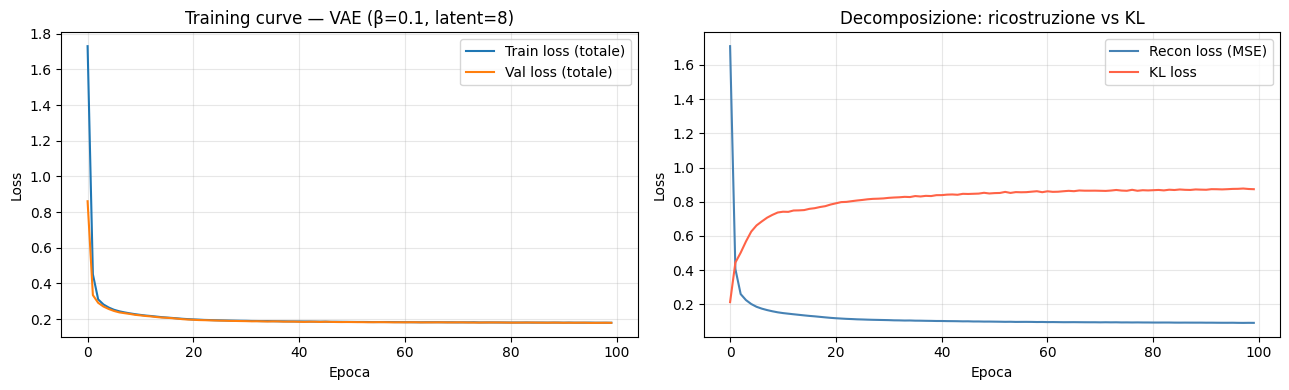

In [8]:
# ── Plot delle loss durante il training ──────────────────────────────────────
# Il VAE ha tre curve da monitorare invece di una sola:
#   - train_loss totale (MSE + beta*KL)
#   - recon_loss: quanto bene il decoder ricostruisce
#   - kl_loss:    quanto la distribuzione latente si discosta da N(0,1)
#
# Cosa aspettarsi:
#   - recon_loss scende: il decoder impara a ricostruire
#   - kl_loss scende: lo spazio latente si avvicina a N(0,1)
#   - Se kl_loss scende molto velocemente rispetto alla recon → beta potrebbe essere troppo alto
#   - Se kl_loss rimane alta → il modello fa fatica a regolarizzare lo spazio latente

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss totale: train vs val (stessa lettura del notebook 02)
ax = axes[0]
ax.plot(train_losses, label='Train loss (totale)')
ax.plot(val_losses,   label='Val loss (totale)')
ax.set_xlabel('Epoca')
ax.set_ylabel('Loss')
ax.set_title(f'Training curve — VAE (β={BETA}, latent={LATENT_DIM})')
ax.legend()
ax.grid(alpha=0.3)

# Decomposizione: recon vs KL (esclusivo del VAE)
ax = axes[1]
ax.plot(train_recon_losses, label='Recon loss (MSE)', color='steelblue')
ax.plot(train_kl_losses,    label='KL loss',          color='tomato')
ax.set_xlabel('Epoca')
ax.set_ylabel('Loss')
ax.set_title('Decomposizione: ricostruzione vs KL')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'vae_training_curve_beta{BETA}.png'), dpi=130, bbox_inches='tight')
plt.show()

---
## 7. Anomaly Score

L'anomaly score è ancora l'**errore di ricostruzione per jet** — uguale all'AE.
La differenza è nella fase di **codifica**: nel VAE l'encoder produce μ e log σ²,
e dobbiamo scegliere come ricavare z da usare nel decoder.

Due modalità, controllate da `ANOMALY_SCORE_MODE`:
- `'mean'`  → usa direttamente **μ** come z (deterministico, un solo passaggio)
- `'sample'`→ campiona z da N(μ, σ²) come in training (stocastico)

Il confronto tra le due modalità è nell'esperimento 4 del tuning (Sezione 9).

In [9]:
def compute_anomaly_scores(model, X_np, mode='mean', n_samples=10,
                            batch_size=4096, device=DEVICE):
    """
    Calcola l'errore di ricostruzione per-jet (anomaly score) su un intero dataset.

    Parametri
    ---------
    model     : VAE addestrato
    X_np      : numpy array (N, D)
    mode      : 'mean'   → z = μ  (deterministico)
                'sample' → z ~ N(μ, σ²), media su n_samples campionamenti
    n_samples : quante volte campionare z se mode='sample' (più alto = più stabile)
    batch_size: jet per batch

    Restituisce
    -----------
    scores : numpy array (N,) — MSE per-jet
    """
    model.eval()
    scores   = []
    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=batch_size)

    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)

            # Ottieni μ e log σ² dall'encoder
            mu, log_var = model.encode(batch)

            if mode == 'mean':
                # Usa μ direttamente come z — nessun campionamento
                # Deterministico: stesso input → stesso score sempre
                z = mu

            elif mode == 'sample':
                # Campiona z n_samples volte e media gli errori di ricostruzione
                # Riduce la varianza introdotta dal campionamento casuale
                mse_samples = []
                for _ in range(n_samples):
                    z      = model.reparameterize(mu, log_var)
                    x_hat  = model.decode(z)
                    mse    = ((batch - x_hat) ** 2).mean(dim=1)   # (batch_size,)
                    mse_samples.append(mse)
                # Media su tutti i campioni → (batch_size,)
                scores.append(torch.stack(mse_samples).mean(dim=0).cpu().numpy())
                continue   # salta il codice sotto, già appended

            # Ricostruzione e MSE per-jet (usato sia per mode='mean' che come base)
            x_hat       = model.decode(z)
            mse_per_jet = ((batch - x_hat) ** 2).mean(dim=1)   # (batch_size,)
            scores.append(mse_per_jet.cpu().numpy())

    return np.concatenate(scores)   # (N,)

In [10]:
# ── Calcolo anomaly scores su TEST-QCD e segnale ─────────────────────────────
# PRIMA volta in cui X_bkg_test e X_sig vengono toccati — nessun leakage.
print(f'Calcolo anomaly scores (mode={ANOMALY_SCORE_MODE})...')
scores_bkg = compute_anomaly_scores(model, X_bkg_test, mode=ANOMALY_SCORE_MODE)
scores_sig = compute_anomaly_scores(model, X_sig,      mode=ANOMALY_SCORE_MODE)

print(f'Background — mean score: {scores_bkg.mean():.4f} ± {scores_bkg.std():.4f}')
print(f'Segnale    — mean score: {scores_sig.mean():.4f} ± {scores_sig.std():.4f}')
print(f'Ratio segnale/background: {scores_sig.mean()/scores_bkg.mean():.2f}x')
print('(ratio > 1 → il segnale viene ricostruito peggio → buon segno)')

Calcolo anomaly scores (mode=mean)...
Background — mean score: 0.0631 ± 0.0377
Segnale    — mean score: 0.1027 ± 0.0550
Ratio segnale/background: 1.63x
(ratio > 1 → il segnale viene ricostruito peggio → buon segno)


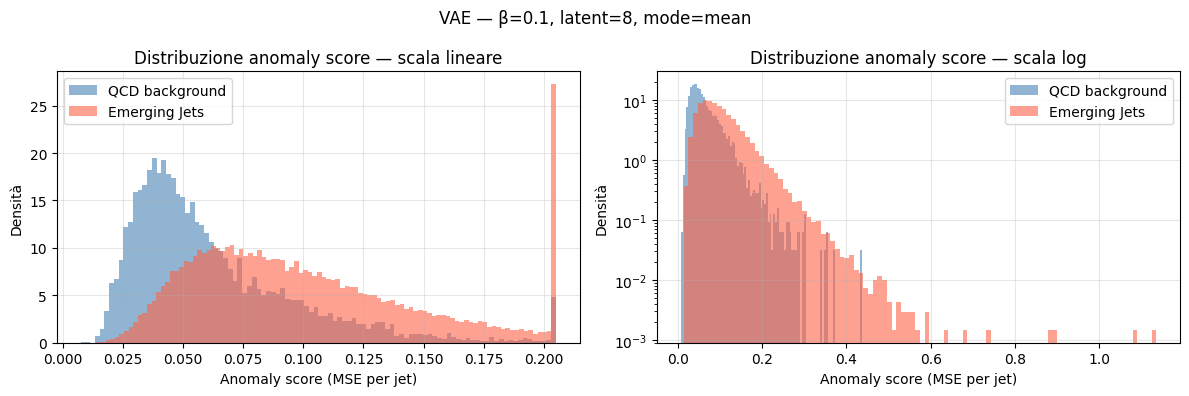

In [11]:
# ── Distribuzione degli anomaly score ────────────────────────────────────────
# Stessa struttura del notebook 02 — clip al 95° percentile solo per la visualizzazione
scores_bkg_plot = np.clip(scores_bkg, 0, np.percentile(scores_sig, 95))
scores_sig_plot = np.clip(scores_sig, 0, np.percentile(scores_sig, 95))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(scores_bkg_plot, bins=100, density=True, alpha=0.6, label='QCD background', color='steelblue')
ax.hist(scores_sig_plot, bins=100, density=True, alpha=0.6, label='Emerging Jets',  color='tomato')
ax.set_xlabel('Anomaly score (MSE per jet)')
ax.set_ylabel('Densità')
ax.set_title('Distribuzione anomaly score — scala lineare')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(scores_bkg, bins=100, density=True, alpha=0.6, label='QCD background', color='steelblue')
ax.hist(scores_sig, bins=100, density=True, alpha=0.6, label='Emerging Jets',  color='tomato')
ax.set_xlabel('Anomaly score (MSE per jet)')
ax.set_ylabel('Densità')
ax.set_title('Distribuzione anomaly score — scala log')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle(f'VAE — β={BETA}, latent={LATENT_DIM}, mode={ANOMALY_SCORE_MODE}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'vae_score_distributions_beta{BETA}.png'), dpi=130, bbox_inches='tight')
plt.show()

---
## 8. Valutazione — ROC curve, AUC e SIC

Identico al notebook 02. Le metriche sono le stesse:
- **AUC**: probabilità che un EJ abbia score più alto di un jet QCD scelto a caso
- **SIC**: quanto migliora la significatività statistica del segnale rispetto a non fare nessun taglio

Avere le stesse metriche permette il confronto diretto con il Flat AE.

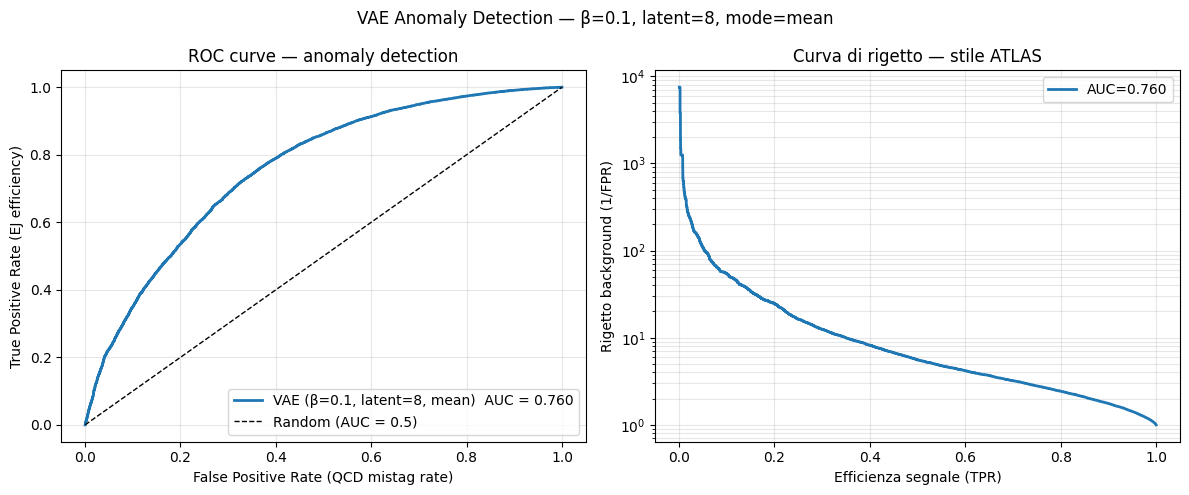

AUC = 0.7603
  Efficienza segnale 30%  →  rigetto background: 12.5x
  Efficienza segnale 50%  →  rigetto background: 5.6x
  Efficienza segnale 70%  →  rigetto background: 3.2x


In [12]:
# ── ROC curve e AUC ──────────────────────────────────────────────────────────
fpr, tpr, roc_auc = compute_roc(scores_bkg, scores_sig)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
plot_roc(fpr, tpr, roc_auc, label=f'VAE (β={BETA}, latent={LATENT_DIM}, {ANOMALY_SCORE_MODE})', ax=ax)

# Curva di rigetto (stile ATLAS): asse y = 1/FPR in scala log
ax = axes[1]
mask_nonzero = fpr > 0
ax.plot(tpr[mask_nonzero], 1.0 / fpr[mask_nonzero], lw=2, label=f'AUC={roc_auc:.3f}')
ax.set_xlabel('Efficienza segnale (TPR)')
ax.set_ylabel('Rigetto background (1/FPR)')
ax.set_title('Curva di rigetto — stile ATLAS')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.suptitle(f'VAE Anomaly Detection — β={BETA}, latent={LATENT_DIM}, mode={ANOMALY_SCORE_MODE}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'vae_roc_beta{BETA}.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'AUC = {roc_auc:.4f}')

for sig_eff in [0.3, 0.5, 0.7]:
    idx     = np.argmin(np.abs(tpr - sig_eff))
    bkg_rej = 1.0 / fpr[idx] if fpr[idx] > 0 else float('inf')
    print(f'  Efficienza segnale {sig_eff*100:.0f}%  →  rigetto background: {bkg_rej:.1f}x')

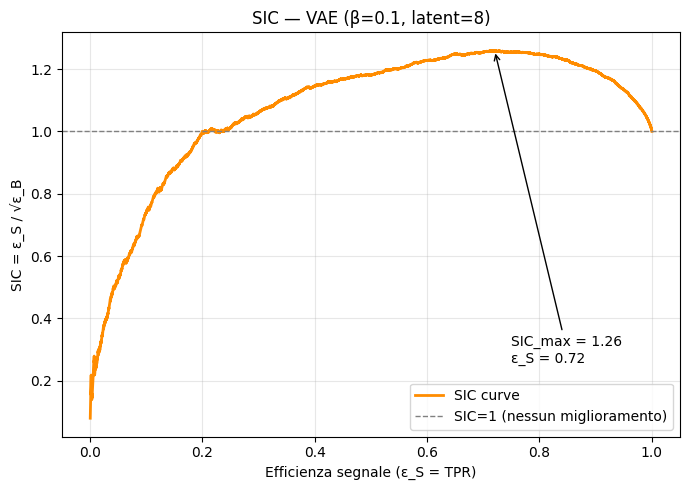

SIC massima     : 1.259
Soglia ottimale : ε_S = 0.72  (tieni 72% degli EJ, rigetti 67.3% del QCD)


In [13]:
# ── SIC — Significance Improvement Characteristic ────────────────────────────
# SIC(ε_S) = ε_S / sqrt(ε_B)
# Misura di quanto migliora la significatività statistica S/sqrt(B)
# rispetto a non applicare nessun taglio.
# Il picco indica la soglia ottimale.

mask = fpr > 0
sic  = tpr[mask] / np.sqrt(fpr[mask])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(tpr[mask], sic, lw=2, color='darkorange', label='SIC curve')
ax.axhline(1.0, color='gray', linestyle='--', lw=1, label='SIC=1 (nessun miglioramento)')
ax.set_xlabel('Efficienza segnale (ε_S = TPR)')
ax.set_ylabel('SIC = ε_S / √ε_B')
ax.set_title(f'SIC — VAE (β={BETA}, latent={LATENT_DIM})')
ax.legend()
ax.grid(alpha=0.3)

sic_max    = sic.max()
tpr_at_max = tpr[mask][np.argmax(sic)]
ax.annotate(
    f'SIC_max = {sic_max:.2f}\nε_S = {tpr_at_max:.2f}',
    xy=(tpr_at_max, sic_max),
    xytext=(min(tpr_at_max + 0.1, 0.75), sic_max - 1.0),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10,
)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'vae_sic_beta{BETA}.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'SIC massima     : {sic_max:.3f}')
print(f'Soglia ottimale : ε_S = {tpr_at_max:.2f}  '
      f'(tieni {tpr_at_max*100:.0f}% degli EJ, '
      f'rigetti {(1 - fpr[mask][np.argmax(sic)])*100:.1f}% del QCD)')

---
## 9. Tuning sistematico

Quattro esperimenti, uno per iperparametro. Teniamo fissi tutti gli altri al valore
di default definito in Sezione 1 e variamo uno alla volta.

| Esperimento | Iperparametro | Valori esplorati |
|---|---|---|
| 1 | `β` (nuovo nel VAE) | 0.1, 0.5, 1.0, 2.0, 4.0 |
| 2 | `latent_dim` | 4, 8, 16, 32 |
| 3 | `dropout` | 0.0, 0.05, 0.1, 0.2 |
| 4 | `anomaly_score_mode` | 'mean', 'sample' |

Per ogni configurazione si addestra un modello da zero, si calcola l'AUC,
e alla fine si stampa la configurazione ottimale trovata.

In [13]:
def train_for_tuning_vae(input_dim, latent_dim, hidden_dims, dropout, beta,
                          train_loader, val_loader, n_val,
                          n_epochs=30, lr=1e-3, patience=7, device=DEVICE):
    """
    Addestra un VAE (solo QCD) e restituisce la miglior val RECONSTRUCTION loss
    (componente MSE, senza KL). Questo criterio e' indipendente da beta e permette
    un confronto equo tra configurazioni diverse — il segnale non viene mai toccato.
    """
    model     = VAE(input_dim, latent_dim, hidden_dims, dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    best_recon, no_improv = float('inf'), 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        for (batch,) in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            x_hat, mu, log_var = model(batch)
            loss, _, _ = vae_loss(batch, x_hat, mu, log_var, beta)
            loss.backward()
            optimizer.step()

        model.eval()
        recon_acc = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(device)
                x_hat, mu, log_var = model(batch)
                # Solo componente MSE (no KL). reduction=mean + peso per batch ->
                # media su tutti gli elementi, confrontabile con la recon del training.
                recon_acc += F.mse_loss(x_hat, batch, reduction='mean').item() * len(batch)
        val_recon = recon_acc / n_val
        scheduler.step(val_recon)

        if val_recon < best_recon:
            best_recon, no_improv = val_recon, 0
        else:
            no_improv += 1
            if no_improv >= patience:
                break

    return best_recon   # val reconstruction loss QCD — nessun segnale, nessuna AUC

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Esperimento 1 — beta (peso della KL divergence)
# Criterio: val RECONSTRUCTION loss (MSE, senza KL) — equo tra diversi beta.
# Usare la total val-loss favorirebbe sempre beta=0 (nessun termine KL).
# Il segnale NON viene toccato.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print('Esperimento 1: beta  (criterio: val reconstruction loss QCD)')
print('=' * 50)
print(f"{'beta':>6} | {'val recon loss':>16}")
print('-' * 50)

beta_results = {}
# 0.05 e 0.01 aggiunti SOLO per caratterizzare la curva (mostrano
# l'appiattimento verso il regime AE); la SELEZIONE resta beta=0.1 (vedi Esp. 2).
for beta_val in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 4.0]:
    recon = train_for_tuning_vae(
        input_dim=INPUT_DIM, latent_dim=LATENT_DIM,
        hidden_dims=HIDDEN_DIMS, dropout=DROPOUT, beta=beta_val,
        train_loader=train_loader, val_loader=val_loader, n_val=n_val,
    )
    beta_results[beta_val] = recon
    print(f'{beta_val:>6.2f} | {recon:>16.6f}')

Esperimento 1: beta  (criterio: val reconstruction loss QCD)
  beta |   val recon loss
--------------------------------------------------
   0.1 |         0.108031
   0.5 |         0.257379
   1.0 |         0.324411
   2.0 |         0.390261
   4.0 |         0.528719


In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Esperimento 2 — Latent dimension
# Criterio: val reconstruction loss QCD. Il segnale NON viene toccato.
# Usa il beta SCELTO (=BETA, non il minimo della recon: sarebbe circolare).
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# NB: qui prima c'era  best_beta = min(beta_results, key=beta_results.get).
# Cambiato di proposito in BETA per evitare una selezione CIRCOLARE: la recon
# scende SEMPRE al calare di beta (meno peso alla KL -> tutta la capacita' va
# in ricostruzione), quindi min() sceglierebbe meccanicamente il beta piu'
# piccolo, fino a beta=0 = autoencoder puro (il termine KL sparisce, la testa
# fc_log_var non viene piu' allenata -> il VAE degenera nel Flat AE del nb 02).
# Per questo aggiungere 0.05/0.01 NON cambia la scelta: beta=0.1 resta il piu'
# piccolo valore che mantiene un latente regolarizzato (KL attiva, vedi plot).
best_beta = BETA   # = 0.1 (scelto), non min(beta_results)
print(f'Esperimento 2: latent dim  (usando beta={best_beta})')
print('=' * 50)
print(f"{'latent':>8} | {'val recon loss':>16}")
print('-' * 50)

latent_results = {}
for ld in [4, 8, 16, 32]:
    recon = train_for_tuning_vae(
        input_dim=INPUT_DIM, latent_dim=ld,
        hidden_dims=HIDDEN_DIMS, dropout=DROPOUT, beta=best_beta,
        train_loader=train_loader, val_loader=val_loader, n_val=n_val,
    )
    latent_results[ld] = recon
    print(f'{ld:>8} | {recon:>16.6f}')

Esperimento 2: latent dim  (usando beta=0.1)
  latent |   val recon loss
--------------------------------------------------
       4 |         0.167659
       8 |         0.102850
      16 |         0.069732
      32 |         0.061105


In [31]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Esperimento 3 — Dropout
# Criterio: val reconstruction loss QCD. Il segnale NON viene toccato.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f'Esperimento 3: dropout  (usando beta={best_beta}, latent={LATENT_DIM})')
print('=' * 50)
print(f"{'dropout':>8} | {'val recon loss':>16}")
print('-' * 50)

dropout_results = {}
for dp in [0.0, 0.05, 0.1, 0.2, 0.3]:
    recon = train_for_tuning_vae(
        input_dim=INPUT_DIM, latent_dim=LATENT_DIM,
        hidden_dims=HIDDEN_DIMS, dropout=dp, beta=best_beta,
        train_loader=train_loader, val_loader=val_loader, n_val=n_val,
    )
    dropout_results[dp] = recon
    print(f'{dp:>8.2f} | {recon:>16.6f}')

Esperimento 3: dropout  (usando beta=0.1, latent=8)
 dropout |   val recon loss
--------------------------------------------------
    0.00 |         0.103750
    0.05 |         0.125576
    0.10 |         0.155939
    0.20 |         0.193079
    0.30 |         0.235375


In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Nota: score mode ('mean' vs 'sample') NON e' nel loop di tuning
# perche' non puo' essere valutato con la sola val-loss QCD — richiede
# il segnale. Il confronto tra le due modalita' e' nella valutazione finale.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("Score mode: confronto 'mean' vs 'sample' nella valutazione finale.")

Score mode: confronto 'mean' vs 'sample' nella valutazione finale.


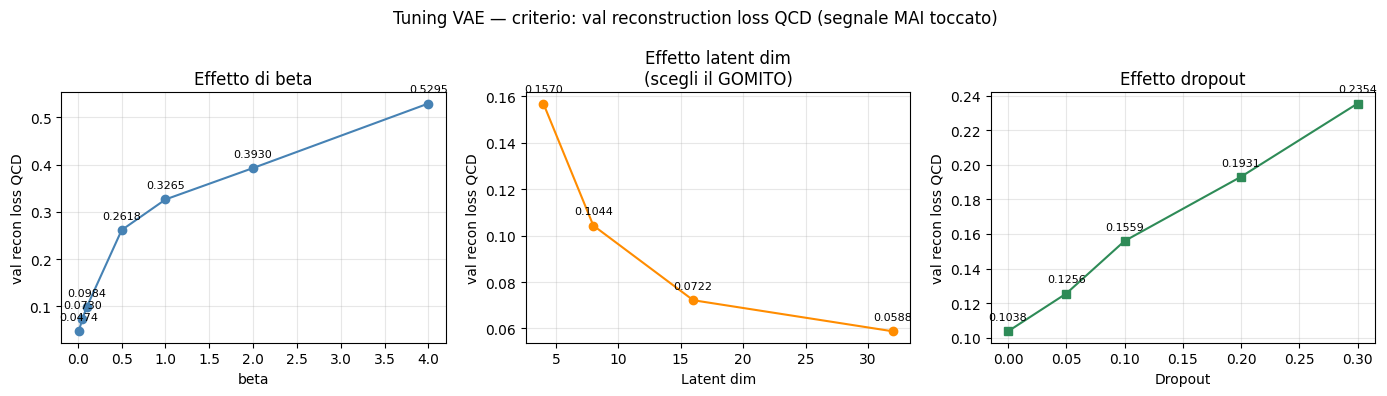


SELEZIONE (criterio: val recon loss QCD; segnale mai osservato)
  Beta    : 0.1
  Latent  : min recon loss a 32 — scegli il GOMITO sul plot (Occam)
  Dropout : 0.0

Aggiorna BETA, LATENT_DIM, DROPOUT in Sezione 1, riesegui il training,
poi esegui la VALUTAZIONE FINALE (ultima cella).


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ks, vs = list(beta_results.keys()), list(beta_results.values())
ax.plot(ks, vs, 'o-', color='steelblue')
ax.set_xlabel('beta'); ax.set_ylabel('val recon loss QCD')
ax.set_title('Effetto di beta'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)

ax = axes[1]
ks, vs = list(latent_results.keys()), list(latent_results.values())
ax.plot(ks, vs, 'o-', color='darkorange')
ax.set_xlabel('Latent dim'); ax.set_ylabel('val recon loss QCD')
ax.set_title('Effetto latent dim\n(scegli il GOMITO)'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)

ax = axes[2]
ks, vs = list(dropout_results.keys()), list(dropout_results.values())
ax.plot(ks, vs, 's-', color='seagreen')
ax.set_xlabel('Dropout'); ax.set_ylabel('val recon loss QCD')
ax.set_title('Effetto dropout'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('Tuning VAE — criterio: val reconstruction loss QCD (segnale MAI toccato)',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'vae_tuning_summary.png'), dpi=130, bbox_inches='tight')
plt.show()

best_dropout = min(dropout_results, key=dropout_results.get)
print('\n' + '=' * 60)
print('SELEZIONE (criterio: val recon loss QCD; segnale mai osservato)')
print('=' * 60)
print(f'  Beta    : {best_beta}')
print(f'  Latent  : min recon loss a {min(latent_results, key=latent_results.get)}'
      f' — scegli il GOMITO sul plot (Occam)')
print(f'  Dropout : {best_dropout}')
print()
print("Aggiorna BETA, LATENT_DIM, DROPOUT in Sezione 1, riesegui il training,")
print("poi esegui la VALUTAZIONE FINALE (ultima cella).")

VALUTAZIONE FINALE (test-QCD + segnale, mai visti nel tuning)
  Configurazione : beta=0.1, latent=8, dropout=0.0
  AUC (mode=mean)  : 0.7603
  AUC (mode=sample): 0.7499
  N test-QCD : 7,500
  N segnale  : 61,966
  Mode scelto    : mean


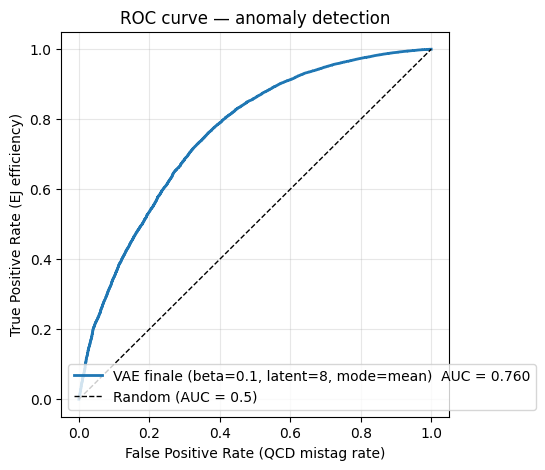


SIC massima : 1.259 @ eps_S = 0.72


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# VALUTAZIONE FINALE — eseguire UNA volta con iperparametri gia' scelti
# ══════════════════════════════════════════════════════════════════════════════
# Prima di eseguire: aggiorna BETA, LATENT_DIM, DROPOUT in Sezione 1
# e riesegui le celle di setup + dati + training cosi' che `model` sia quello
# con gli iperparametri ottimali.
#
# Confronto score mode 'mean' vs 'sample' — fatto qui, non nel tuning,
# perche' richiede il segnale.

from sklearn.metrics import roc_auc_score

scores_bkg_test = compute_anomaly_scores(model, X_bkg_test, mode='mean')
scores_sig_final = compute_anomaly_scores(model, X_sig,     mode='mean')
_, _, auc_mean = compute_roc(scores_bkg_test, scores_sig_final)

scores_bkg_samp = compute_anomaly_scores(model, X_bkg_test, mode='sample', n_samples=10)
scores_sig_samp = compute_anomaly_scores(model, X_sig,      mode='sample', n_samples=10)
_, _, auc_sample = compute_roc(scores_bkg_samp, scores_sig_samp)

print('=' * 60)
print('VALUTAZIONE FINALE (test-QCD + segnale, mai visti nel tuning)')
print('=' * 60)
print(f'  Configurazione : beta={BETA}, latent={LATENT_DIM}, dropout={DROPOUT}')
print(f'  AUC (mode=mean)  : {auc_mean:.4f}')
print(f'  AUC (mode=sample): {auc_sample:.4f}')
print(f'  N test-QCD : {len(scores_bkg_test):,}')
print(f'  N segnale  : {len(scores_sig_final):,}')

# Usa il mode migliore per il plot finale
if auc_mean >= auc_sample:
    fpr, tpr, roc_auc = compute_roc(scores_bkg_test, scores_sig_final)
    best_mode = 'mean'
else:
    fpr, tpr, roc_auc = compute_roc(scores_bkg_samp, scores_sig_samp)
    best_mode = 'sample'

print(f'  Mode scelto    : {best_mode}')
plot_roc(fpr, tpr, roc_auc,
         label=f'VAE finale (beta={BETA}, latent={LATENT_DIM}, mode={best_mode})',
         save_path=os.path.join(PLOTS_DIR, 'vae_roc_finale.png'))
plt.show()

# SIC
mask_sic = fpr > 0
sic = tpr[mask_sic] / np.sqrt(fpr[mask_sic])
sic_max = sic.max()
eps_s_opt = tpr[mask_sic][sic.argmax()]
print(f'\nSIC massima : {sic_max:.3f} @ eps_S = {eps_s_opt:.2f}')

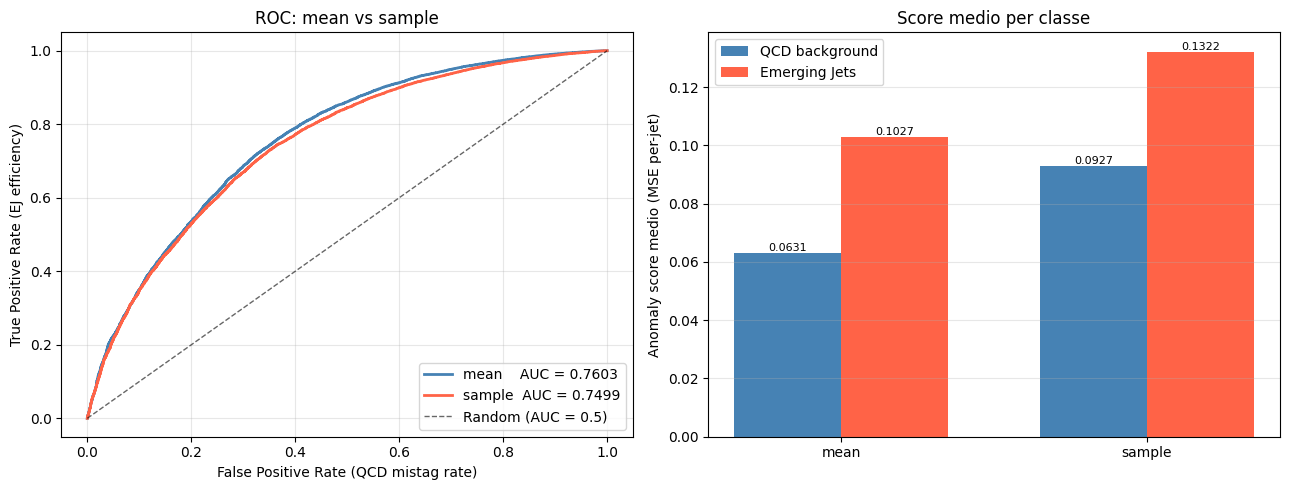

Delta AUC (mean - sample) = +0.0103  ->  modalita migliore: mean


In [15]:
# == Confronto score mode: 'mean' vs 'sample' ================================
# Cella PURAMENTE AGGIUNTIVA: riusa gli score gia' calcolati nella valutazione
# finale (cella sopra) e NON modifica nulla del resto del notebook.
fpr_m, tpr_m, auc_m = compute_roc(scores_bkg_test, scores_sig_final)
fpr_s, tpr_s, auc_s = compute_roc(scores_bkg_samp,  scores_sig_samp)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (1) Overlay delle due ROC
ax = axes[0]
ax.plot(fpr_m, tpr_m, lw=2, color='steelblue', label=f'mean    AUC = {auc_m:.4f}')
ax.plot(fpr_s, tpr_s, lw=2, color='tomato',    label=f'sample  AUC = {auc_s:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (QCD mistag rate)')
ax.set_ylabel('True Positive Rate (EJ efficiency)')
ax.set_title('ROC: mean vs sample')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# (2) Score medio per classe, raggruppato per modalita'
ax = axes[1]
means_qcd = [scores_bkg_test.mean(), scores_bkg_samp.mean()]
means_ej  = [scores_sig_final.mean(), scores_sig_samp.mean()]
x = np.arange(2)            # 0 = mean, 1 = sample
w = 0.35
b1 = ax.bar(x - w/2, means_qcd, w, color='steelblue', label='QCD background')
b2 = ax.bar(x + w/2, means_ej,  w, color='tomato',    label='Emerging Jets')
ax.set_xticks(x)
ax.set_xticklabels(['mean', 'sample'])
ax.set_ylabel('Anomaly score medio (MSE per-jet)')
ax.set_title('Score medio per classe')
ax.legend()
ax.grid(alpha=0.3, axis='y')
for rects in (b1, b2):
    for r in rects:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height(),
                f'{r.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'vae_scoremode_confronto.png'), dpi=120, bbox_inches='tight')
plt.show()

best = 'mean' if auc_m >= auc_s else 'sample'
print(f'Delta AUC (mean - sample) = {auc_m - auc_s:+.4f}  ->  modalita migliore: {best}')


Quello che conta non è l'altezza assoluta delle barre ma il rapporto EJ/QCD in
  ciascun metodo — ed è coerente col fatto che mean ha AUC migliore.

## Scelta di design: score *whitened* + densita' nel latente

Due raffinamenti rispetto all'MSE medio: (1) **whitening** dell'errore di ricostruzione (pesato per la varianza di ricostruzione del QCD); (2) **distanza di Mahalanobis** del codice `mu` rispetto alla nuvola latente del QCD - un jet anomalo *o* ricostruisce male *o* cade dove il QCD non vive nel latente. I due termini, standardizzati sul QCD, vengono sommati. Confrontiamo con il baseline e adottiamo il migliore.

AUC baseline (MSE): 0.7603  |  whitened+latente: 0.8004  |  delta +0.0401


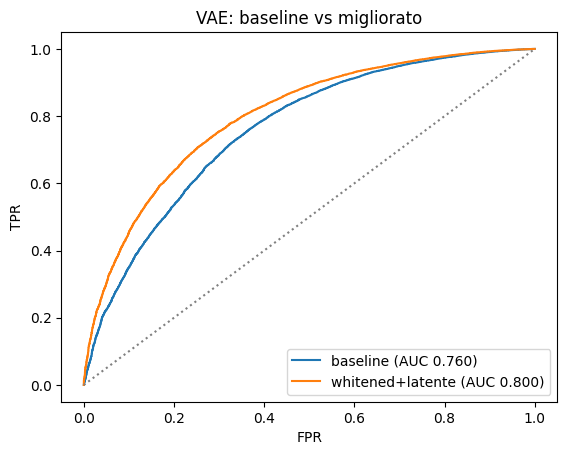

In [16]:
# === DESIGN CHOICE (whitened) ===
import numpy as np, torch
def _vae_mu_err(X, bs=4096):
    model.eval(); mus=[]; ers=[]
    with torch.no_grad():
        for st in range(0, len(X), bs):
            xb = torch.tensor(X[st:st+bs], dtype=torch.float32, device=DEVICE)
            mu,_ = model.encode(xb); xh = model.decode(mu)
            mus.append(mu.cpu().numpy()); ers.append(((xb - xh)**2).cpu().numpy())
    return np.concatenate(mus), np.concatenate(ers)
mu_tr,e_tr = _vae_mu_err(X_bkg_train); mu_vl,e_vl = _vae_mu_err(X_bkg_val)
mu_te,e_te = _vae_mu_err(X_bkg_test); mu_sg,e_sg = _vae_mu_err(X_sig)
scores_bkg_base, scores_sig_base = e_te.mean(1), e_sg.mean(1)            # baseline MSE (z=mu)
_var = e_tr.mean(0) + 1e-6
rec_te,rec_sg,rec_vl = (e_te/_var).mean(1),(e_sg/_var).mean(1),(e_vl/_var).mean(1)
_m = mu_tr.mean(0); _cov = np.cov(mu_tr.T) + 1e-4*np.eye(mu_tr.shape[1]); _inv = np.linalg.inv(_cov)
_maha = lambda mu: np.einsum('ni,ij,nj->n', mu-_m, _inv, mu-_m)
mah_te,mah_sg,mah_vl = _maha(mu_te),_maha(mu_sg),_maha(mu_vl)
_z = lambda a,r: (a-r.mean())/(r.std()+1e-9)
scores_bkg_official = _z(rec_te,rec_vl) + _z(mah_te,mah_vl)
scores_sig_official = _z(rec_sg,rec_vl) + _z(mah_sg,mah_vl)
_ab = compute_roc(scores_bkg_base, scores_sig_base)[2]
_aw = compute_roc(scores_bkg_official, scores_sig_official)[2]
print(f'AUC baseline (MSE): {_ab:.4f}  |  whitened+latente: {_aw:.4f}  |  delta {_aw-_ab:+.4f}')
import matplotlib.pyplot as plt
for _s in ('base','official'):
    f,t,a = compute_roc(eval(f'scores_bkg_{_s}'), eval(f'scores_sig_{_s}'))
    plt.plot(f,t,label=f'{"baseline" if _s=="base" else "whitened+latente"} (AUC {a:.3f})')
plt.plot([0,1],[0,1],':',c='gray'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('VAE: baseline vs migliorato'); plt.legend(); plt.show()

## Export per la Task 3 - salvataggio degli anomaly-score

Salva lo score **ufficiale** del modello (lo *whitened* dove adottato, altrimenti il baseline) e, per sicurezza, anche il **baseline** (`scores_*_base`), piu' gli indici `idx_sig`/`idx_bkg` per agganciare decay length e massa. Ricaricati dal notebook `08` per il confronto, senza riallenare.

In [17]:
# === TASK3 EXPORT ===
# Salva gli anomaly-score (ufficiale + baseline) per il confronto in 08_evaluation_task3_locale.
import os, numpy as np
TASK3_DIR = "C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores"
os.makedirs(TASK3_DIR, exist_ok=True)
# score ufficiale del modello (whitened se definito, altrimenti baseline del notebook)
sb = (scores_bkg_official if 'scores_bkg_official' in dir() else
      scores_bkg_test if 'scores_bkg_test' in dir() else scores_bkg)
ss = (scores_sig_official if 'scores_sig_official' in dir() else
      scores_sig_final if 'scores_sig_final' in dir() else scores_sig)
sb = np.asarray(sb, np.float32); ss = np.asarray(ss, np.float32)
idx_sig = np.arange(len(ss), dtype=np.int32)
_it = idx_test if 'idx_test' in dir() else (ite if 'ite' in dir() else None)
idx_bkg = np.asarray(_it, np.int32) if _it is not None else np.arange(len(sb), np.int32)
assert len(idx_bkg) == len(sb)
extra = {}
if 'scores_bkg_base' in dir() and 'scores_sig_base' in dir():
    extra['scores_bkg_base'] = np.asarray(scores_bkg_base, np.float32)
    extra['scores_sig_base'] = np.asarray(scores_sig_base, np.float32)
_path = os.path.join(TASK3_DIR, "vae.npz")
np.savez_compressed(_path, scores_bkg=sb, scores_sig=ss, idx_sig=idx_sig, idx_bkg=idx_bkg,
                    model_name="VAE", **extra)
print(f"[Task 3] Salvato {_path} | bkg {len(sb):,} | sig {len(ss):,}" + (" (+baseline)" if extra else ""))
try:
    from sklearn.metrics import roc_auc_score
    y = np.r_[np.zeros(len(sb)), np.ones(len(ss))]
    print(f"         AUC ufficiale: {roc_auc_score(y, np.r_[sb, ss]):.4f}")
except Exception as e:
    print("         (AUC quick-check non disponibile)", e)

[Task 3] Salvato C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores\vae.npz | bkg 7,500 | sig 61,966 (+baseline)
         AUC ufficiale: 0.8004
